In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [20]:
df = pd.read_csv('Titanic.csv')
df

,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [21]:
print("=== Info ===")
print(df.info())

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   gender    1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB
None


In [22]:
print("\n=== Describe ===")
print(df.describe(include='all'))


=== Describe ===
             pclass              name gender          age        sibsp  \
count   1309.000000              1309   1309  1046.000000  1309.000000   
unique          NaN              1307      2          NaN          NaN   
top             NaN  Kelly, Mr. James   male          NaN          NaN   
freq            NaN                 2    843          NaN          NaN   
mean       2.294882               NaN    NaN    29.881135     0.498854   
std        0.837836               NaN    NaN    14.413500     1.041658   
min        1.000000               NaN    NaN     0.166700     0.000000   
25%        2.000000               NaN    NaN    21.000000     0.000000   
50%        3.000000               NaN    NaN    28.000000     0.000000   
75%        3.000000               NaN    NaN    39.000000     1.000000   
max        3.000000               NaN    NaN    80.000000     8.000000   

              parch    ticket         fare        cabin embarked     survived  
count   1309.

In [23]:
print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Missing Values ===
pclass         0
name           0
gender         0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
survived       0
dtype: int64


In [30]:
print("\n=== Value Counts ===")
for col in ['gender', 'embarked', 'Pclass']:  # Iterate through the desired columns
    if col in df.columns:  # Check if the column exists
      print(f"{col}:\n{df[col].value_counts()}\n")
    else:
      print(f"Column '{col}' not found in the DataFrame.\n")



=== Value Counts ===
gender:
gender
male      843
female    466
Name: count, dtype: int64

embarked:
embarked
S    914
C    270
Q    123
Name: count, dtype: int64

Column 'Pclass' not found in the DataFrame.



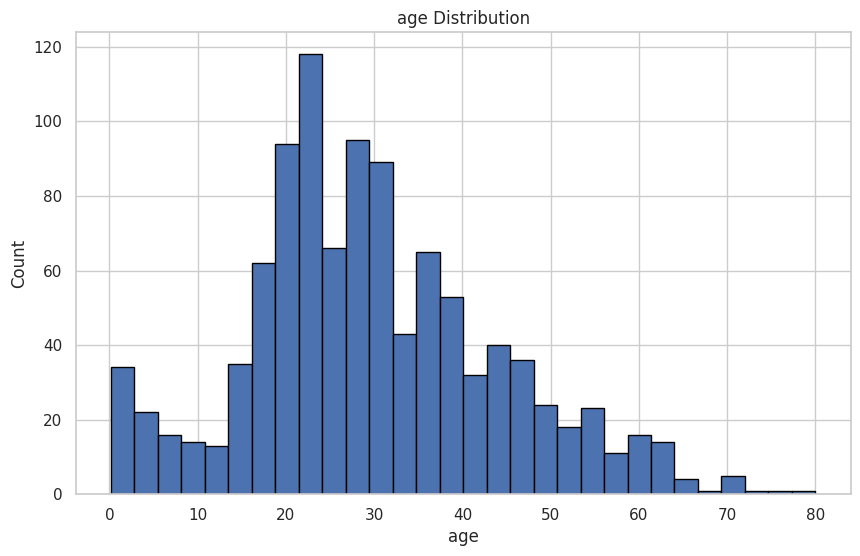

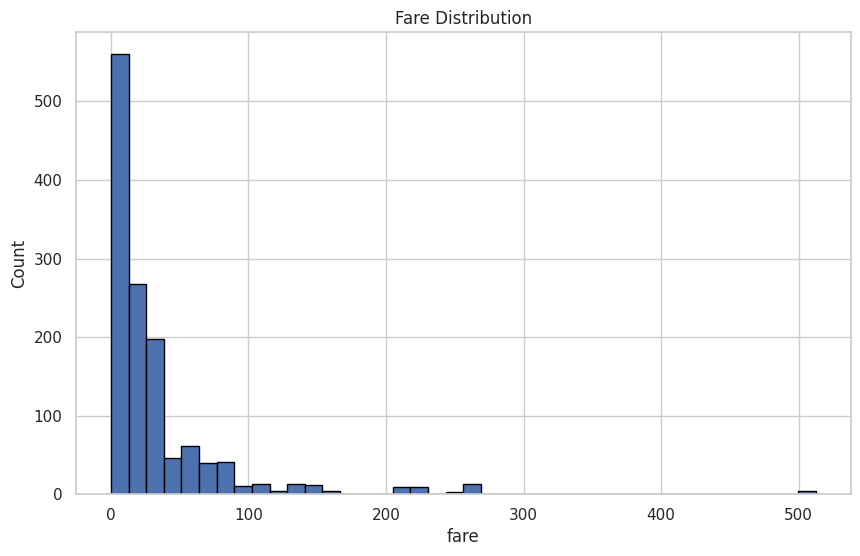

In [33]:
#Identify relationships and trends
#Plot histograms, boxplots, scatterplots
# Histogram for Age, Fare
df['age'].hist(bins=30, edgecolor='black')
plt.title('age Distribution')
plt.xlabel('age')
plt.ylabel('Count')
plt.show()
df['fare'].hist(bins=40, edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('fare')
plt.ylabel('Count')
plt.show()


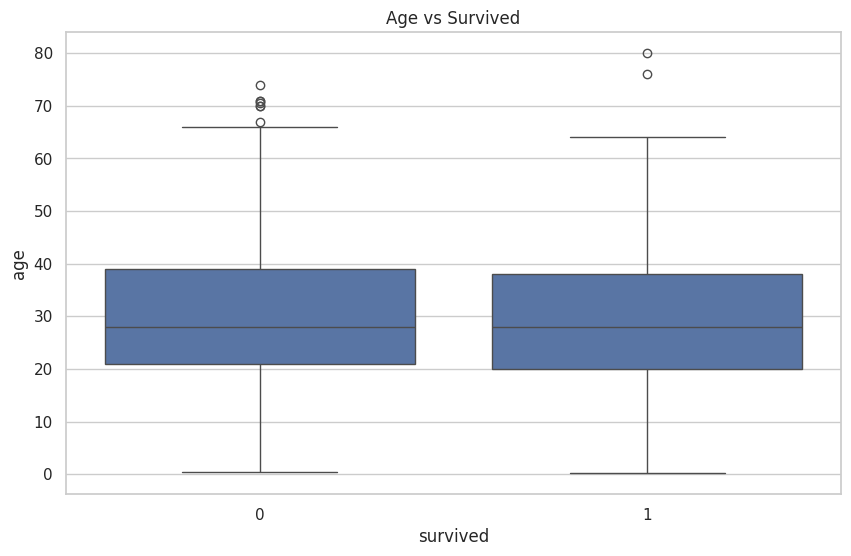

In [35]:
## Boxplot of Age by Survived
sns.boxplot(x='survived', y='age', data=df)
plt.title('Age vs Survived')
plt.show()


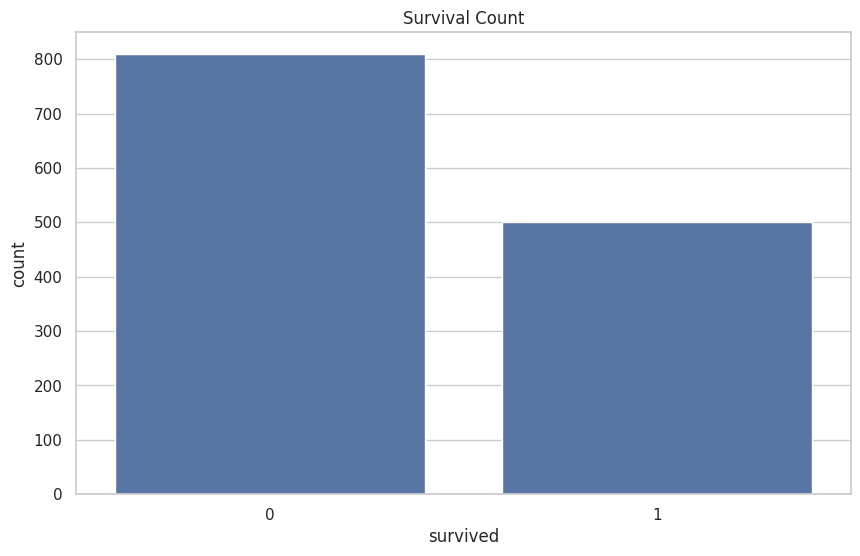

In [36]:
## Countplot for Survived
sns.countplot(x='survived', data=df)
plt.title('Survival Count')
plt.show()

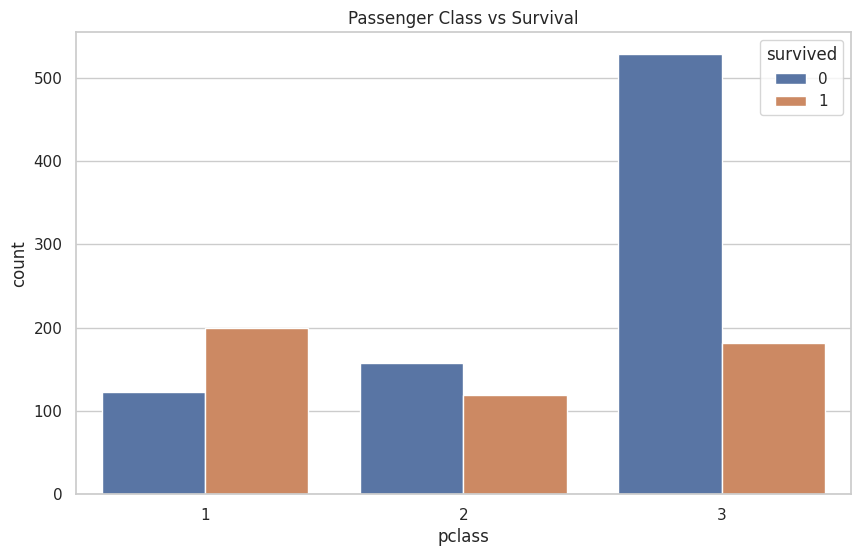

In [38]:
## Countplot for Pclass
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Passenger Class vs Survival')
plt.show()

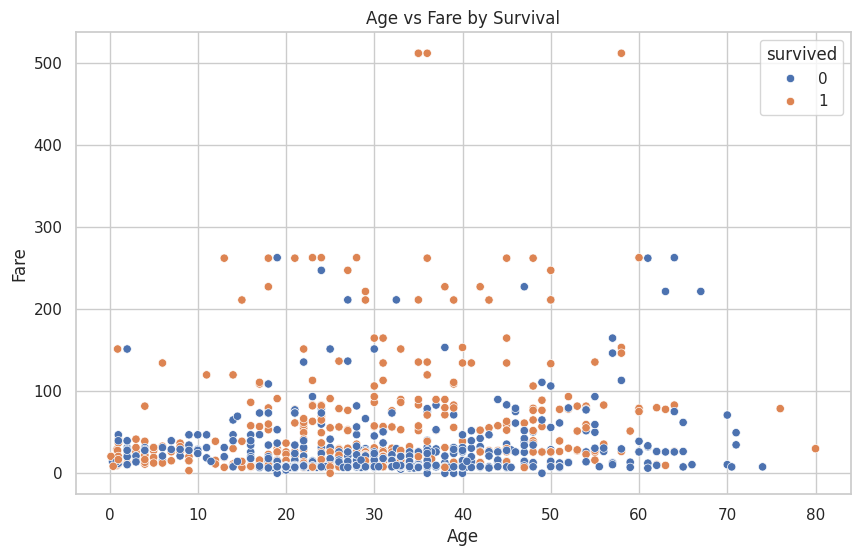

In [42]:
## Scatter Plot: Age vs Fare colored by Survival
sns.scatterplot(x='age', y='fare', hue='survived', data=df)
plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


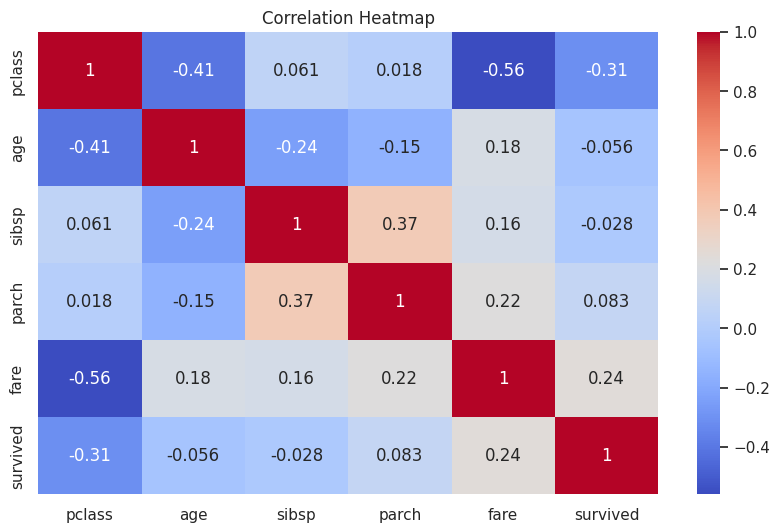

In [39]:
#Visualizations
## Heatmap of correlations
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

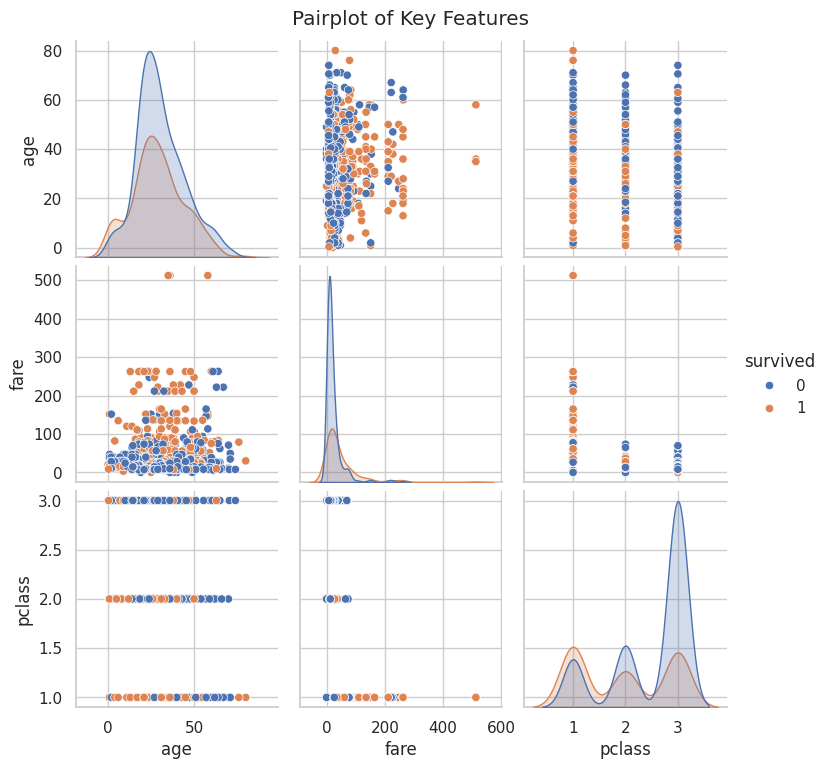

In [41]:
## Pairplot (for selected numeric features)
sns.pairplot(df[['survived', 'age', 'fare', 'pclass']], hue='survived')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

### Observations

1. Age is right-skewed and ranges mostly between 20 and 40.
2. Most passengers paid a low fare, but some paid significantly higher.
3. Boxplot shows younger passengers had slightly higher survival chances.
4. More people from Pclass 1 survived compared to Pclass 3.
5. Heatmap shows Fare and Pclass are moderately correlated.
6. Survival is correlated with Pclass and Fare.
7. Scatter plot shows that high-fare passengers had better survival rates, often in younger age brackets.
"""

### Summary of Findings

- Survival rate was higher among females, younger passengers, and first-class travelers.
- Pclass and Fare are key indicators related to survival.
- Missing values exist in Age, Cabin, and Embarked columns.
- Feature engineering can be done using titles from names, family size, etc.
"""